In [1]:
from pymongo import MongoClient
import pandas as pd

client = MongoClient("mongodb://localhost:27017/")
db = client["taller4_db"]

datos = list(db.raw_data.find())

df = pd.DataFrame(datos)

list(df.columns)

['_id',
 'id',
 'name',
 'xAntibody',
 'images',
 'levels',
 'types',
 'attributes',
 'fields',
 'releaseDate',
 'descriptions',
 'skills',
 'priorEvolutions',
 'nextEvolutions']

In [2]:
df.iloc[0]

_id                                         6a2376c1b69cac3f914648dc
id                                                                 1
name                                                          Agumon
xAntibody                                                      False
images             [{'href': 'https://digi-api.com/images/digimon...
levels                                 [{'id': 4, 'level': 'Child'}]
types                                 [{'id': 1, 'type': 'Reptile'}]
attributes                       [{'id': 4, 'attribute': 'Vaccine'}]
fields             [{'id': 8, 'field': 'Deep Savers', 'image': 'h...
releaseDate                                                     1997
descriptions       [{'origin': 'reference_book', 'language': 'jap...
skills             [{'id': 1, 'skill': 'Baby Flame', 'translation...
priorEvolutions    [{'id': 1304, 'digimon': 'Algomon (Baby II)', ...
nextEvolutions     [{'id': 493, 'digimon': 'Agnimon', 'condition'...
Name: 0, dtype: object

In [3]:
df[['name','levels','types','attributes']].head()

,name,levels,types,attributes
0,Agumon,"[{'id': 4, 'level': 'Child'}]","[{'id': 1, 'type': 'Reptile'}]","[{'id': 4, 'attribute': 'Vaccine'}]"
1,Airdramon,"[{'id': 2, 'level': 'Adult'}]","[{'id': 2, 'type': 'Mythical Beast'}]","[{'id': 4, 'attribute': 'Vaccine'}]"
2,Angemon,"[{'id': 2, 'level': 'Adult'}]","[{'id': 3, 'type': 'Angel'}]","[{'id': 4, 'attribute': 'Vaccine'}]"
3,Betamon,"[{'id': 4, 'level': 'Child'}]","[{'id': 4, 'type': 'Amphibian'}]","[{'id': 3, 'attribute': 'Virus'}]"
4,Birdramon,"[{'id': 2, 'level': 'Adult'}]","[{'id': 5, 'type': 'Giant Bird'}]","[{'id': 1, 'attribute': 'Data'}, {'id': 4, 'at..."


In [5]:
df["nivel"] = df["levels"].apply(
    lambda x: x[0]["level"] if isinstance(x, list) and len(x) > 0 else None
)

df["tipo"] = df["types"].apply(
    lambda x: x[0]["type"] if isinstance(x, list) and len(x) > 0 else None
)

df["atributo"] = df["attributes"].apply(
    lambda x: x[0]["attribute"] if isinstance(x, list) and len(x) > 0 else None
)

df["num_habilidades"] = df["skills"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

In [6]:
df[
    [
        "name",
        "nivel",
        "tipo",
        "atributo",
        "num_habilidades"
    ]
].head()

,name,nivel,tipo,atributo,num_habilidades
0,Agumon,Child,Reptile,Vaccine,18
1,Airdramon,Adult,Mythical Beast,Vaccine,7
2,Angemon,Adult,Angel,Vaccine,8
3,Betamon,Child,Amphibian,Virus,5
4,Birdramon,Adult,Giant Bird,Data,8


In [7]:
df.columns

Index(['_id', 'id', 'name', 'xAntibody', 'images', 'levels', 'types',
       'attributes', 'fields', 'releaseDate', 'descriptions', 'skills',
       'priorEvolutions', 'nextEvolutions', 'nivel', 'tipo', 'atributo',
       'num_habilidades'],
      dtype='str')

In [8]:
df["nivel"].value_counts()

nivel
Adult      22
Perfect    11
Child       5
Baby I      3
Baby II     2
Name: count, dtype: int64

In [9]:
df["tipo"].value_counts().head(10)

tipo
Cyborg            4
Slime             3
Dinosaur          3
Reptile           2
Mythical Beast    2
Angel             2
Giant Bird        2
Lesser            2
Aquatic           2
Insect            2
Name: count, dtype: int64

In [10]:
df["atributo"].value_counts()

atributo
Data       15
Virus      13
Vaccine    10
Free        4
Name: count, dtype: int64

In [11]:
df["num_habilidades"].mean()

np.float64(4.9)

In [12]:
df[
    ["name","num_habilidades"]
].sort_values(
    "num_habilidades",
    ascending=False
).head(10)

,name,num_habilidades
0,Agumon,18
15,Gabumon,17
33,Greymon,13
37,Angewomon,13
32,Garurumon,9
2,Angemon,8
4,Birdramon,8
21,Numemon,8
1,Airdramon,7
20,Monzaemon,7


Matplotlib is building the font cache; this may take a moment.


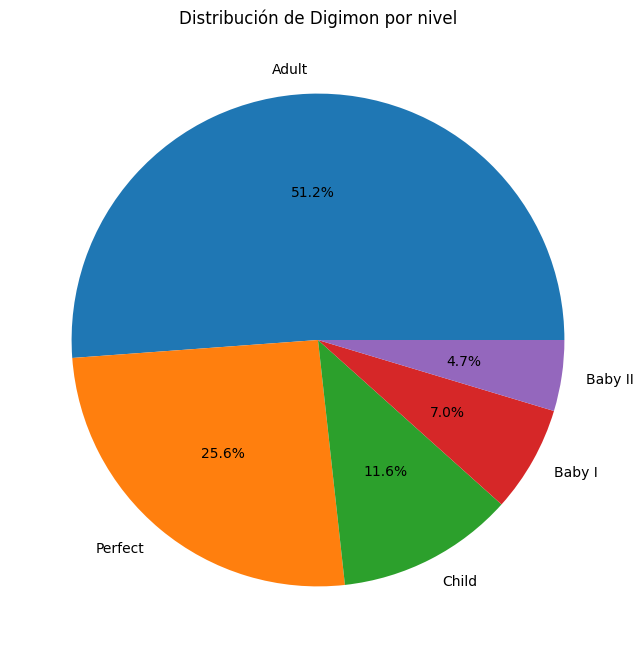

In [13]:
import matplotlib.pyplot as plt

df["nivel"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(8,8)
)

plt.title("Distribución de Digimon por nivel")
plt.ylabel("")
plt.show()

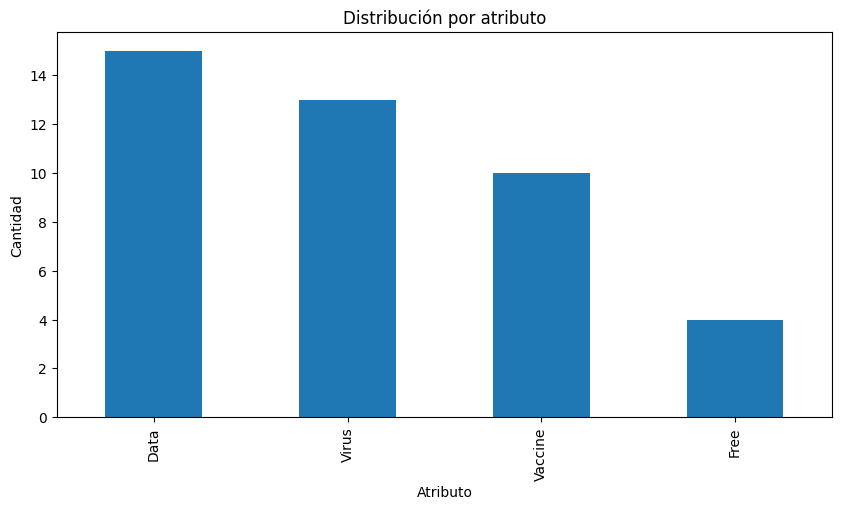

In [14]:
df["atributo"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Distribución por atributo")
plt.xlabel("Atributo")
plt.ylabel("Cantidad")
plt.show()

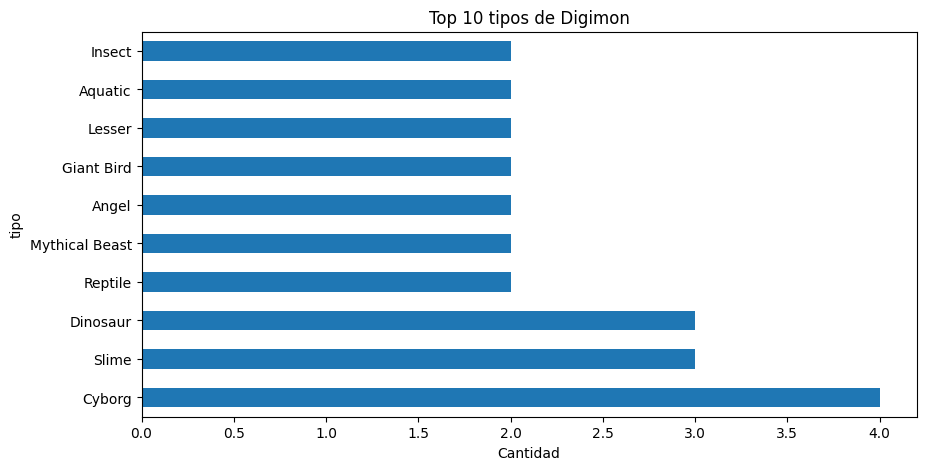

In [15]:
df["tipo"].value_counts().head(10).plot(
    kind="barh",
    figsize=(10,5)
)

plt.title("Top 10 tipos de Digimon")
plt.xlabel("Cantidad")
plt.show()